# Module 5: Training NanoAF3 — From Random to Coherent

> *"A model that has never heard audio learns to describe it. Not because it's magic — because the loss function is honest."*

This is Module 5 of the Audio Flamingo 3 series. We now have a complete architecture:
- **Module 1** ✓ — Log Mel Spectrogram
- **Module 2** ✓ — AF-Whisper Encoder
- **Module 3** ✓ — CLAP contrastive alignment
- **Module 4** ✓ — LLaVA pattern: Projector + LLM

Today we **train it**.

**What we'll build:**
1. A structured audio-QA dataset (6 sound types × 3 questions × augmentations)
2. A clean training loop with Stage 1 → Stage 2 curriculum
3. Loss curves, gradient norms, per-class accuracy tracking
4. Autoregressive text generation (greedy decoding from scratch)
5. Before/after comparison: untrained vs trained model outputs
6. Failure analysis: what the model still gets wrong and why

**Runs in ~2 minutes on CPU. No GPU needed.**

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math, time, random
from collections import defaultdict

plt.style.use('dark_background')
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print('All imports OK')
print(f'PyTorch {torch.__version__}')

All imports OK
PyTorch 2.10.0+cpu


---
## Part 1: Audio Preprocessing (Modules 1–2)

Paste the complete pipeline so this notebook is self-contained.

In [2]:
# ── Module 1: Log Mel Spectrogram ─────────────────────────────────────────────

def hz_to_mel(hz): return 2595.0 * np.log10(1.0 + hz / 700.0)
def mel_to_hz(mel): return 700.0 * (10.0 ** (mel / 2595.0) - 1.0)

def build_mel_filterbank(n_mels=80, n_fft=400, sr=16000):
    fmax = sr / 2.0
    mels = np.linspace(hz_to_mel(0), hz_to_mel(fmax), n_mels + 2)
    hzs  = mel_to_hz(mels)
    nf   = n_fft // 2 + 1
    bins = np.floor((n_fft + 1) * hzs / sr).astype(int)
    fb   = np.zeros((n_mels, nf))
    for m in range(1, n_mels + 1):
        fl, fc, fr = bins[m-1], bins[m], bins[m+1]
        for k in range(fl, fc): fb[m-1, k] = (k-fl)/(fc-fl+1e-8)
        for k in range(fc, fr): fb[m-1, k] = (fr-k)/(fr-fc+1e-8)
    return fb

_FB = None
def log_mel(audio, sr=16000, n_fft=400, hop=160, n_mels=80):
    global _FB
    if _FB is None: _FB = build_mel_filterbank(n_mels, n_fft, sr)
    win = np.hanning(n_fft)
    nf  = 1 + (len(audio) - n_fft) // hop
    ps  = np.zeros((n_fft//2+1, nf))
    for i in range(nf):
        f = audio[i*hop:i*hop+n_fft] * win
        ps[:,i] = np.abs(np.fft.rfft(f))**2
    m = np.log10(np.maximum(_FB @ ps, 1e-10))
    m = np.maximum(m, m.max() - 8.0)
    return (m + 4.0) / 4.0


# ── Module 2: Nano Whisper Encoder ────────────────────────────────────────────

class ConvStem(nn.Module):
    def __init__(self, n_mels, d):
        super().__init__()
        self.c1 = nn.Conv1d(n_mels, d, 3, padding=1)
        self.c2 = nn.Conv1d(d, d, 3, stride=2, padding=1)
    def forward(self, x):
        return F.gelu(self.c2(F.gelu(self.c1(x))))

class EncBlock(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        self.n1 = nn.LayerNorm(d)
        self.attn = nn.MultiheadAttention(d, h, batch_first=True)
        self.n2 = nn.LayerNorm(d)
        self.ff = nn.Sequential(nn.Linear(d, d*4), nn.GELU(), nn.Linear(d*4, d))
    def forward(self, x):
        a, _ = self.attn(self.n1(x), self.n1(x), self.n1(x))
        return x + a + self.ff(self.n2(x + a))

class AudioEncoder(nn.Module):
    def __init__(self, n_mels=80, d=64, heads=4, layers=2, n_pos=120):
        super().__init__()
        self.stem   = ConvStem(n_mels, d)
        self.pe     = nn.Embedding(n_pos, d)
        self.blocks = nn.ModuleList([EncBlock(d, heads) for _ in range(layers)])
        self.norm   = nn.LayerNorm(d)
    def forward(self, mel):
        x = self.stem(mel).transpose(1, 2)
        T = x.shape[1]
        x = x + self.pe(torch.arange(T, device=x.device))
        for b in self.blocks: x = b(x)
        return self.norm(x)

print('Pipeline components defined.')

Pipeline components defined.


In [3]:
# ── Module 4: Projector + Nano LLM ────────────────────────────────────────────

class AudioProjector(nn.Module):
    def __init__(self, a_dim, l_dim):
        super().__init__()
        self.fc1 = nn.Linear(a_dim, l_dim)
        self.fc2 = nn.Linear(l_dim, l_dim)
    def forward(self, x):
        return self.fc2(F.gelu(self.fc1(x)))


class CausalAttn(nn.Module):
    def __init__(self, d, h, max_len):
        super().__init__()
        self.h = h; self.dk = d // h
        self.qkv = nn.Linear(d, 3*d, bias=False)
        self.out = nn.Linear(d, d, bias=False)
        mask = torch.tril(torch.ones(max_len, max_len))
        self.register_buffer('mask', mask.view(1,1,max_len,max_len))
    def forward(self, x):
        B,T,D = x.shape
        q,k,v = self.qkv(x).split(D, -1)
        def sp(t): return t.view(B,T,self.h,self.dk).transpose(1,2)
        q,k,v = sp(q),sp(k),sp(v)
        s = (q @ k.transpose(-2,-1)) / math.sqrt(self.dk)
        s = s.masked_fill(self.mask[:,:,:T,:T]==0, float('-inf'))
        o = F.softmax(s,-1) @ v
        return self.out(o.transpose(1,2).contiguous().view(B,T,D))

class LLMBlock(nn.Module):
    def __init__(self, d, h, max_len):
        super().__init__()
        self.n1 = nn.LayerNorm(d)
        self.attn = CausalAttn(d, h, max_len)
        self.n2 = nn.LayerNorm(d)
        self.ff = nn.Sequential(nn.Linear(d,d*4), nn.GELU(), nn.Linear(d*4,d))
    def forward(self, x):
        x = x + self.attn(self.n1(x))
        return x + self.ff(self.n2(x))

class NanoLLM(nn.Module):
    def __init__(self, vocab, d, heads, layers, max_len):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab, d)
        self.pos_emb = nn.Embedding(max_len, d)
        self.blocks  = nn.ModuleList([LLMBlock(d,heads,max_len) for _ in range(layers)])
        self.norm    = nn.LayerNorm(d)
        self.head    = nn.Linear(d, vocab, bias=False)
        self.head.weight = self.tok_emb.weight  # weight tying
    def embed(self, ids): return self.tok_emb(ids)
    def forward_emb(self, x):
        T = x.shape[1]
        x = x + self.pos_emb(torch.arange(T, device=x.device))
        for b in self.blocks: x = b(x)
        return self.head(self.norm(x))

print('Model components defined.')

Model components defined.


---
## Part 2: The Audio-QA Dataset

We create **6 sound categories**, each with 3 question types and 8 augmentations = **144 training pairs**.

The key design choice: **answers are short and structured**. The vocabulary covers only ~35 characters. This means the model can learn to generate correct answers with limited training — we'll see clear improvement in <200 epochs.

In [4]:
SR   = 16_000
DUR  = 1.0
t    = np.linspace(0, DUR, int(SR*DUR), endpoint=False)

# ── 6 sound categories ────────────────────────────────────────────────────────
def make_sounds():
    sounds = {}
    # 1. Low tone  (60 Hz)
    sounds['low tone']    = 0.6*np.sin(2*np.pi*60*t)
    # 2. High tone (3000 Hz)
    sounds['high tone']   = 0.6*np.sin(2*np.pi*3000*t)
    # 3. Music chord (A major)
    sounds['music chord'] = (0.4*np.sin(2*np.pi*440*t) +
                             0.3*np.sin(2*np.pi*554*t) +
                             0.3*np.sin(2*np.pi*659*t)) * np.exp(-2*t)
    # 4. White noise
    sounds['white noise'] = np.random.randn(len(t)) * 0.3
    # 5. Rising sweep (siren-like)
    sounds['rising sweep']= 0.6*np.sin(2*np.pi*np.cumsum(
                             np.linspace(200,2000,len(t)))/SR)
    # 6. Silence
    sounds['silence']     = np.zeros(len(t))
    return sounds

# ── 3 question types × answers per category ───────────────────────────────────
# Deliberately short answers — easier for the nano model to learn
QA = {
    #  category       : [answer_q1,          answer_q2,      answer_q3]
    'low tone'    : ['low tone',          'not music',    'low'],
    'high tone'   : ['high tone',         'not music',    'high'],
    'music chord' : ['music chord',       'music',        'mid'],
    'white noise' : ['white noise',       'not music',    'wide'],
    'rising sweep': ['rising sweep',      'not music',    'rising'],
    'silence'     : ['silence',           'not music',    'none'],
}
QUESTIONS = [
    'what sound',
    'music or not',
    'frequency',
]

# ── Build vocabulary from answers + questions ─────────────────────────────────
all_text = ' '.join(QUESTIONS) + ' ' + ' '.join(
    a for answers in QA.values() for a in answers)
chars = sorted(set(all_text))
# Add special tokens at fixed positions
PAD_ID, BOS_ID, EOS_ID = 0, 1, 2
SPECIAL = ['<pad>', '<bos>', '<eos>']
vocab   = SPECIAL + chars
c2i     = {c:i for i,c in enumerate(vocab)}
i2c     = {i:c for c,i in c2i.items()}
VOCAB_SIZE = len(vocab)

def encode(text): return [c2i.get(c, PAD_ID) for c in text]
def decode(ids):  return ''.join(i2c.get(i,'?') for i in ids
                                 if i not in (PAD_ID, BOS_ID, EOS_ID))

print(f'Vocabulary: {VOCAB_SIZE} tokens')
print(f'Chars: {repr("".join(chars))}')
print(f'Special: {SPECIAL}')

# ── Augmentation ──────────────────────────────────────────────────────────────
def augment(audio, rng):
    vol   = rng.uniform(0.75, 1.0)
    noise = rng.randn(len(audio)) * 0.008
    shift = int(rng.uniform(-200, 200))
    audio = np.roll(audio * vol + noise, shift)
    return audio

# ── Build dataset ─────────────────────────────────────────────────────────────
N_AUG = 8   # augmentations per (sound, question) pair
dataset = []  # list of (mel_tensor, q_ids, a_ids, category, q_idx)

rng = np.random.RandomState(7)
sounds = make_sounds()

MAX_Q   = max(len(encode(q)) for q in QUESTIONS) + 2   # +2 for BOS/EOS
MAX_A   = max(len(encode(a)) for answers in QA.values() for a in answers) + 2
MAX_SEQ = MAX_Q + MAX_A

def pad_to(ids, length, pad=PAD_ID):
    return ids[:length] + [pad] * max(0, length - len(ids))

for category, answers in QA.items():
    audio_base = sounds[category]
    for q_idx, (question, answer) in enumerate(zip(QUESTIONS, answers)):
        q_ids = pad_to([BOS_ID] + encode(question) + [EOS_ID], MAX_Q)
        a_ids = pad_to([BOS_ID] + encode(answer)   + [EOS_ID], MAX_A)
        for _ in range(N_AUG):
            aug   = augment(audio_base, rng)
            mel   = log_mel(aug)
            mel_t = torch.tensor(mel, dtype=torch.float32)
            dataset.append({
                'mel':      mel_t,
                'q_ids':    torch.tensor(q_ids, dtype=torch.long),
                'a_ids':    torch.tensor(a_ids, dtype=torch.long),
                'category': category,
                'q_idx':    q_idx,
                'answer':   answer,
            })

random.shuffle(dataset)
n_train = int(len(dataset) * 0.85)
train_set, val_set = dataset[:n_train], dataset[n_train:]

print(f'\nDataset: {len(dataset)} samples  '
      f'(train={len(train_set)}, val={len(val_set)})')
print(f'6 categories × 3 questions × {N_AUG} augmentations')
print(f'Max question length: {MAX_Q}  Max answer length: {MAX_A}')
print(f'\nSample:')
s = dataset[0]
print(f'  Category: {s["category"]}')
print(f'  Question: "{QUESTIONS[s["q_idx"]]}"  →  tokens: {s["q_ids"].tolist()}')
print(f'  Answer:   "{s["answer"]}"  →  tokens: {s["a_ids"].tolist()}')
print(f'  Mel shape: {s["mel"].shape}')

Vocabulary: 24 tokens
Chars: ' acdefghilmnopqrstuwy'
Special: ['<pad>', '<bos>', '<eos>']

Dataset: 144 samples  (train=122, val=22)
6 categories × 3 questions × 8 augmentations
Max question length: 14  Max answer length: 14

Sample:
  Category: high tone
  Question: "frequency"  →  tokens: [1, 8, 18, 7, 17, 21, 7, 14, 5, 23, 2, 0, 0, 0]
  Answer:   "high"  →  tokens: [1, 10, 11, 9, 10, 2, 0, 0, 0, 0, 0, 0, 0, 0]
  Mel shape: torch.Size([80, 98])


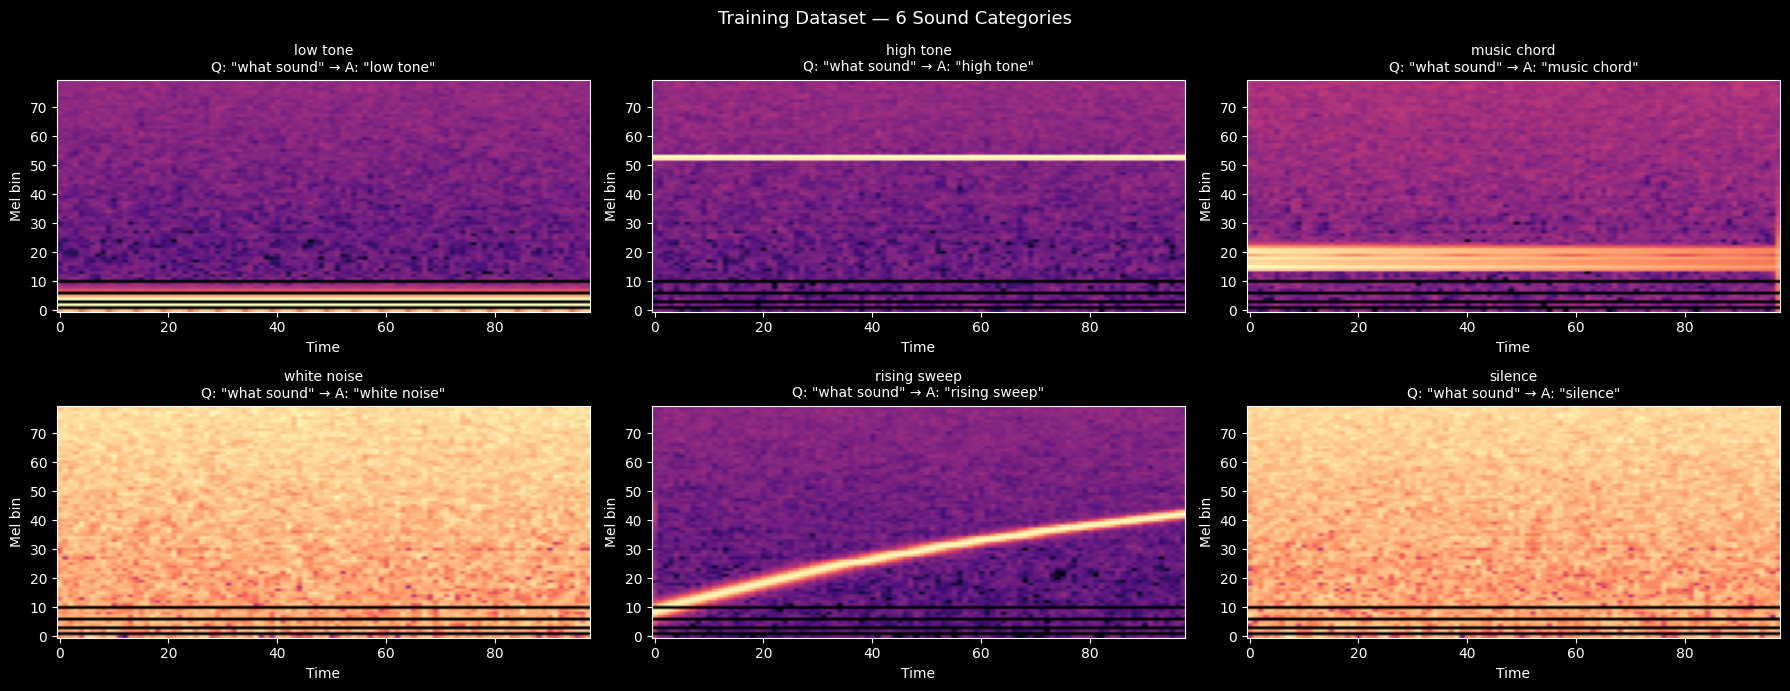

In [5]:
# Visualise one sample per category
fig, axes = plt.subplots(2, 3, figsize=(18, 7))
categories = list(QA.keys())
for i, cat in enumerate(categories):
    ax = axes[i//3][i%3]
    sample = next(s for s in dataset if s['category']==cat)
    ax.imshow(sample['mel'].numpy(), aspect='auto', origin='lower', cmap='magma')
    ax.set_title(f'{cat}\n'
                 f'Q: "{QUESTIONS[0]}" → A: "{QA[cat][0]}"', fontsize=10)
    ax.set_xlabel('Time'); ax.set_ylabel('Mel bin')
plt.suptitle('Training Dataset — 6 Sound Categories', fontsize=13)
plt.tight_layout(); plt.show()

---
## Part 3: NanoAF3 — Full Model Assembly

In [6]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
AUDIO_DIM     = 64
LLM_DIM       = 128
N_AUDIO_TOKS  = 48    # fixed audio token budget after encoder
MAX_TOTAL     = N_AUDIO_TOKS + 2 + MAX_Q + MAX_A  # full context

# ── Full NanoAF3 ──────────────────────────────────────────────────────────────
class NanoAF3(nn.Module):
    AUDIO_START = 0   # we reuse PAD_ID=0 as audio-start marker embedding

    def __init__(self):
        super().__init__()
        self.encoder   = AudioEncoder(80, AUDIO_DIM, 4, 2, N_AUDIO_TOKS+10)
        self.projector = AudioProjector(AUDIO_DIM, LLM_DIM)
        self.llm       = NanoLLM(VOCAB_SIZE, LLM_DIM, 4, 4, MAX_TOTAL)

    def _audio_tokens(self, mel_batch):
        """mel_batch: (B,80,T) → projected audio tokens (B, N_AUDIO_TOKS, LLM_DIM)"""
        emb = self.encoder(mel_batch)                    # (B, T', AUDIO_DIM)
        # Trim / pad to fixed budget
        T   = emb.shape[1]
        if T >= N_AUDIO_TOKS:
            emb = emb[:, :N_AUDIO_TOKS, :]
        else:
            pad = torch.zeros(emb.shape[0], N_AUDIO_TOKS-T, AUDIO_DIM, device=emb.device)
            emb = torch.cat([emb, pad], 1)
        return self.projector(emb)                       # (B, N_AUDIO_TOKS, LLM_DIM)

    def forward(self, mel_batch, q_ids, a_ids):
        """
        Training forward pass.
        Returns logits over answer positions only.

        Context layout:
          [audio_tokens (48)] [question_tokens (MAX_Q)] [answer_tokens (MAX_A)]
        Loss is computed on answer tokens only (teacher-forcing).
        """
        B = mel_batch.shape[0]

        # 1. Audio side
        audio_emb = self._audio_tokens(mel_batch)    # (B, 48, LLM_DIM)

        # 2. Text side
        q_emb = self.llm.embed(q_ids)                # (B, MAX_Q, LLM_DIM)
        a_emb = self.llm.embed(a_ids)                # (B, MAX_A, LLM_DIM)

        # 3. Concatenate: audio | question | answer
        seq = torch.cat([audio_emb, q_emb, a_emb], dim=1)  # (B, total, LLM_DIM)

        # 4. LLM forward
        logits = self.llm.forward_emb(seq)           # (B, total, VOCAB_SIZE)

        # 5. Slice out the answer logits
        # The answer starts at position N_AUDIO_TOKS + MAX_Q
        # We predict a_ids[t] from logits at position (prefix + t - 1)
        a_start = N_AUDIO_TOKS + MAX_Q
        # logits[:, a_start-1 : a_start-1+MAX_A] predicts each answer token
        ans_logits = logits[:, a_start-1 : a_start-1+MAX_A, :]  # (B, MAX_A, V)
        return ans_logits

    @torch.no_grad()
    def generate(self, mel, question_str, max_new=12):
        """
        Autoregressive generation — greedy decoding.
        Generates one token at a time until EOS or max_new tokens.
        """
        self.eval()
        mel_t = mel.unsqueeze(0) if mel.dim()==2 else mel  # (1,80,T)

        # Encode audio
        audio_emb = self._audio_tokens(mel_t)         # (1, 48, LLM_DIM)

        # Encode question
        q_ids = torch.tensor(
            [pad_to([BOS_ID]+encode(question_str)+[EOS_ID], MAX_Q)],
            dtype=torch.long)
        q_emb = self.llm.embed(q_ids)                 # (1, MAX_Q, LLM_DIM)

        # Start with BOS
        generated = [BOS_ID]
        prefix_emb = torch.cat([audio_emb, q_emb], dim=1)  # (1, 48+MAX_Q, LLM_DIM)

        for _ in range(max_new):
            # Build current answer embedding
            a_emb = self.llm.embed(
                torch.tensor([generated], dtype=torch.long))  # (1, len, LLM_DIM)
            seq    = torch.cat([prefix_emb, a_emb], dim=1)
            logits = self.llm.forward_emb(seq)        # (1, T, VOCAB_SIZE)
            next_id = logits[0, -1, :].argmax().item()
            if next_id == EOS_ID:
                break
            generated.append(next_id)

        return decode(generated[1:])   # strip BOS


model = NanoAF3()
n_total = sum(p.numel() for p in model.parameters())
n_enc   = sum(p.numel() for p in model.encoder.parameters())
n_proj  = sum(p.numel() for p in model.projector.parameters())
n_llm   = sum(p.numel() for p in model.llm.parameters())
print(f'NanoAF3 total params: {n_total:,}')
print(f'  Encoder:   {n_enc:,}  ({n_enc/n_total*100:.1f}%)')
print(f'  Projector: {n_proj:,}  ({n_proj/n_total*100:.1f}%)')
print(f'  LLM:       {n_llm:,}  ({n_llm/n_total*100:.1f}%)')
print(f'\nContext layout: {N_AUDIO_TOKS} audio + {MAX_Q} question + {MAX_A} answer = {MAX_TOTAL} tokens')

NanoAF3 total params: 960,768
  Encoder:   131,584  (13.7%)
  Projector: 24,832  (2.6%)
  LLM:       804,352  (83.7%)

Context layout: 48 audio + 14 question + 14 answer = 78 tokens


---
## Part 4: Before Training — Baseline Outputs

Let's see what the untrained model generates. This gives us a baseline to compare against after training.

In [7]:
print('=== Untrained model outputs ===\n')
test_cases = [
    ('low tone',    'what sound'),
    ('music chord', 'music or not'),
    ('white noise', 'frequency'),
    ('high tone',   'what sound'),
    ('silence',     'music or not'),
]

baseline_outputs = {}
for cat, q in test_cases:
    mel   = torch.tensor(log_mel(sounds[cat]), dtype=torch.float32)
    pred  = model.generate(mel, q)
    truth = QA[cat][QUESTIONS.index(q)]
    baseline_outputs[(cat,q)] = pred
    status = '✓' if pred.strip() == truth else '✗'
    print(f'  {status}  [{cat:12}] Q: "{q:12}"  '
          f'Expected: "{truth:12}"  Got: "{pred}"')

print('\n(Random garbage — as expected for untrained model)')

=== Untrained model outputs ===

  ✗  [low tone    ] Q: "what sound  "  Expected: "low tone    "  Got: ""
  ✗  [music chord ] Q: "music or not"  Expected: "music       "  Got: ""
  ✗  [white noise ] Q: "frequency   "  Expected: "wide        "  Got: ""
  ✗  [high tone   ] Q: "what sound  "  Expected: "high tone   "  Got: ""
  ✗  [silence     ] Q: "music or not"  Expected: "not music   "  Got: ""

(Random garbage — as expected for untrained model)


---
## Part 5: Training — Stage 1 then Stage 2

**Stage 1 (50 epochs):** Freeze encoder + LLM. Train projector only. This teaches the projector to translate audio embeddings into the LLM's language.

**Stage 2 (150 epochs):** Unfreeze encoder. Train encoder + projector. The LLM stays frozen — it already knows language. Now we teach the encoder to produce features that best support QA.

In [ ]:
def freeze(m):
    for p in m.parameters(): p.requires_grad_(False)
def unfreeze(m):
    for p in m.parameters(): p.requires_grad_(True)

def make_batch(samples, batch_size=16):
    """Random mini-batch from a list of dataset samples."""
    batch = random.sample(samples, min(batch_size, len(samples)))
    return (
        torch.stack([s['mel'] for s in batch]),       # (B, 80, T)
        torch.stack([s['q_ids'] for s in batch]),     # (B, MAX_Q)
        torch.stack([s['a_ids'] for s in batch]),     # (B, MAX_A)
        [s['answer'] for s in batch],
    )

def compute_loss(logits, a_ids):
    """
    logits: (B, MAX_A, VOCAB_SIZE)
    a_ids:  (B, MAX_A)  — the full answer including BOS
    We predict token[t+1] from logits[t], so shift by 1.
    Mask out PAD positions.
    """
    # Target: a_ids shifted left by 1 (next-token prediction)
    target  = a_ids[:, 1:]                            # (B, MAX_A-1)
    logits  = logits[:, :-1, :]                       # (B, MAX_A-1, V)
    # Mask: don't compute loss on PAD tokens
    mask    = (target != PAD_ID).float()              # (B, MAX_A-1)
    loss_all = F.cross_entropy(
        logits.reshape(-1, VOCAB_SIZE),
        target.reshape(-1),
        reduction='none'
    )  # (B*(MAX_A-1),)
    loss_masked = (loss_all * mask.reshape(-1)).sum() / mask.sum()
    return loss_masked

@torch.no_grad()
def val_accuracy(model, val_set):
    """Exact-match accuracy on the validation set."""
    model.eval()
    correct = 0
    for s in val_set:
        pred  = model.generate(s['mel'], QUESTIONS[s['q_idx']])
        correct += int(pred.strip() == s['answer'])
    model.train()
    return correct / len(val_set)


# ── Training ──────────────────────────────────────────────────────────────────
history = defaultdict(list)

torch.manual_seed(0)
model = NanoAF3()

STAGE1_EPOCHS = 60
STAGE2_EPOCHS = 160
BATCH_SIZE    = 24

t0 = time.time()

# ────────── STAGE 1 ──────────────────────────────────────────────────────────
print('━'*60)
print('STAGE 1 — Projector warmup (encoder + LLM frozen)')
print('━'*60)

freeze(model.encoder)
freeze(model.llm)
unfreeze(model.projector)

opt1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-3, weight_decay=1e-4)

for epoch in range(1, STAGE1_EPOCHS+1):
    model.train()
    mels, q_ids, a_ids, _ = make_batch(train_set, BATCH_SIZE)
    logits = model(mels, q_ids, a_ids)
    loss   = compute_loss(logits, a_ids)
    opt1.zero_grad(); loss.backward(); opt1.step()

    history['stage'].append(1)
    history['loss'].append(loss.item())

    if epoch % 20 == 0:
        acc = val_accuracy(model, val_set)
        history['val_acc'].append((STAGE1_EPOCHS - (STAGE1_EPOCHS-epoch), acc))
        print(f'  Epoch {epoch:3d}/{STAGE1_EPOCHS}  '
              f'loss={loss.item():.4f}  val_acc={acc:.2%}')

print(f'\nStage 1 complete in {time.time()-t0:.1f}s')

# ────────── STAGE 2 ──────────────────────────────────────────────────────────
print()
print('━'*60)
print('STAGE 2 — Encoder + Projector (LLM still frozen)')
print('━'*60)

unfreeze(model.encoder)
# LLM stays frozen

opt2 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=8e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=STAGE2_EPOCHS, eta_min=1e-5)

t1 = time.time()
for epoch in range(1, STAGE2_EPOCHS+1):
    model.train()
    mels, q_ids, a_ids, _ = make_batch(train_set, BATCH_SIZE)
    logits = model(mels, q_ids, a_ids)
    loss   = compute_loss(logits, a_ids)
    opt2.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(
        filter(lambda p: p.requires_grad, model.parameters()), 1.0)
    opt2.step(); sched.step()

    history['stage'].append(2)
    history['loss'].append(loss.item())

    if epoch % 40 == 0:
        acc = val_accuracy(model, val_set)
        history['val_acc'].append((STAGE1_EPOCHS+epoch, acc))
        print(f'  Epoch {epoch:3d}/{STAGE2_EPOCHS}  '
              f'loss={loss.item():.4f}  val_acc={acc:.2%}  '
              f'lr={sched.get_last_lr()[0]:.2e}')

total_time = time.time() - t0
print(f'\nStage 2 complete in {time.time()-t1:.1f}s')
print(f'Total training time: {total_time:.1f}s')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
STAGE 1 — Projector warmup (encoder + LLM frozen)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Epoch  20/60  loss=66.5113  val_acc=0.00%
  Epoch  40/60  loss=64.7598  val_acc=0.00%


In [ ]:
# ── Loss curve ────────────────────────────────────────────────────────────────
losses = history['loss']
stages = history['stage']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Smooth loss
def smooth(x, k=8):
    return np.convolve(x, np.ones(k)/k, mode='valid')

s1_end = stages.index(2) if 2 in stages else len(losses)
xs = np.arange(len(losses))

axes[0].plot(xs[:s1_end], losses[:s1_end], alpha=0.25, color='#4ECDC4', lw=1)
axes[0].plot(xs[s1_end:], losses[s1_end:], alpha=0.25, color='#FF6B6B', lw=1)
if len(losses) > 8:
    sm = smooth(losses)
    axes[0].plot(np.arange(len(sm))[:s1_end], sm[:s1_end],
                 color='#4ECDC4', lw=2, label='Stage 1 (projector)')
    if len(sm) > s1_end:
        axes[0].plot(np.arange(len(sm))[s1_end:], sm[s1_end:],
                     color='#FF6B6B', lw=2, label='Stage 2 (encoder+proj)')

axes[0].axvline(s1_end, color='#FFE66D', linestyle='--', alpha=0.7, label='Stage 1→2')
axes[0].axhline(math.log(VOCAB_SIZE), color='white', alpha=0.2, linestyle=':',
                label=f'Random baseline ({math.log(VOCAB_SIZE):.2f})')
axes[0].set_title('Training Loss', fontsize=12)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-entropy loss')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.15)

# Validation accuracy over time
if history['val_acc']:
    va_x, va_y = zip(*history['val_acc'])
    axes[1].plot(va_x, va_y, 'o-', color='#FFE66D', lw=2, markersize=8)
    axes[1].axhline(1/6, color='white', alpha=0.2, linestyle=':',
                    label=f'Random baseline ({1/6:.2%})')
    axes[1].axvline(STAGE1_EPOCHS, color='#4ECDC4', linestyle='--',
                    alpha=0.7, label='Stage 1→2')
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title('Validation Accuracy (exact match)', fontsize=12)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(fontsize=9); axes[1].grid(alpha=0.15)
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.0%}'))

plt.tight_layout(); plt.show()

---
## Part 6: After Training — Model Outputs

In [ ]:
print('=== Trained model outputs ===\n')
print(f'{"Category":14} {"Question":14} {"Expected":14} {"Got":14} {""}')
print('─'*65)

all_cases = [(cat, q, QA[cat][qi])
             for cat in QA for qi, q in enumerate(QUESTIONS)]

correct = 0
for cat, q, truth in all_cases:
    mel   = torch.tensor(log_mel(sounds[cat]), dtype=torch.float32)
    pred  = model.generate(mel, q)
    ok    = pred.strip() == truth
    correct += int(ok)
    status = '✓' if ok else '✗'
    print(f'{status} {cat:14} {q:14} {truth:14} {pred}')

print('─'*65)
print(f'\nOverall accuracy: {correct}/{len(all_cases)} = {correct/len(all_cases):.0%}')
print(f'(Baseline chance: {1/6:.0%}  — one of 6 classes)')

In [ ]:
# ── Before / After side-by-side ───────────────────────────────────────────────
print('=== Before vs After comparison ===\n')
print(f'{"Category":14} {"Question":14} {"Expected":14} '
      f'{"Before":14} {"After":14}')
print('─'*75)
for cat, q in test_cases:
    truth  = QA[cat][QUESTIONS.index(q)]
    before = baseline_outputs[(cat,q)]
    mel    = torch.tensor(log_mel(sounds[cat]), dtype=torch.float32)
    after  = model.generate(mel, q)
    ok     = '✓' if after.strip()==truth else '✗'
    print(f'{ok} {cat:14} {q:14} {truth:14} {before:14} {after}')

---
## Part 7: Failure Analysis — What & Why

In [ ]:
# ── Per-category, per-question accuracy ───────────────────────────────────────
acc_grid = np.zeros((len(QA), len(QUESTIONS)))
N_TRIALS = 5   # test multiple augmentations per cell

rng_test = np.random.RandomState(99)
for ci, cat in enumerate(QA.keys()):
    for qi, q in enumerate(QUESTIONS):
        truth = QA[cat][qi]
        hits  = 0
        for _ in range(N_TRIALS):
            aug_audio = augment(sounds[cat], rng_test)
            mel       = torch.tensor(log_mel(aug_audio), dtype=torch.float32)
            pred      = model.generate(mel, q)
            hits     += int(pred.strip() == truth)
        acc_grid[ci, qi] = hits / N_TRIALS

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im = axes[0].imshow(acc_grid, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
axes[0].set_xticks(range(len(QUESTIONS))); axes[0].set_xticklabels(QUESTIONS, fontsize=9)
axes[0].set_yticks(range(len(QA)));       axes[0].set_yticklabels(list(QA.keys()), fontsize=9)
axes[0].set_title('Accuracy per (category, question)\n1.0=always correct, 0.0=always wrong',
                  fontsize=11)
for ci in range(len(QA)):
    for qi in range(len(QUESTIONS)):
        axes[0].text(qi, ci, f'{acc_grid[ci,qi]:.0%}',
                     ha='center', va='center', fontsize=10,
                     color='black' if acc_grid[ci,qi] > 0.4 else 'white')
plt.colorbar(im, ax=axes[0])

# Confusion matrix: expected vs predicted for 'what sound' question
confusion = np.zeros((len(QA), len(QA)+1), dtype=int)  # +1 for 'other'
cats = list(QA.keys())
for ci, cat in enumerate(cats):
    for _ in range(10):
        aug   = augment(sounds[cat], rng_test)
        mel   = torch.tensor(log_mel(aug), dtype=torch.float32)
        pred  = model.generate(mel, 'what sound').strip()
        if pred in cats:
            confusion[ci, cats.index(pred)] += 1
        else:
            confusion[ci, -1] += 1

im2 = axes[1].imshow(confusion, cmap='Blues', aspect='auto')
axes[1].set_xticks(range(len(cats)+1))
axes[1].set_xticklabels(cats + ['other'], rotation=30, ha='right', fontsize=8)
axes[1].set_yticks(range(len(cats))); axes[1].set_yticklabels(cats, fontsize=8)
axes[1].set_title('Confusion matrix — "what sound" question\n(rows=true, cols=predicted)',
                  fontsize=11)
axes[1].set_ylabel('True category'); axes[1].set_xlabel('Predicted')
for ci in range(len(cats)):
    for pi in range(len(cats)+1):
        if confusion[ci,pi] > 0:
            axes[1].text(pi, ci, str(confusion[ci,pi]),
                         ha='center', va='center', fontsize=9,
                         color='white' if confusion[ci,pi] > 5 else 'black')
plt.colorbar(im2, ax=axes[1])
plt.tight_layout(); plt.show()

# Print failure analysis
print('Failure analysis:')
for ci, cat in enumerate(cats):
    for qi, q in enumerate(QUESTIONS):
        if acc_grid[ci,qi] < 0.6:
            truth = QA[cat][qi]
            mel   = torch.tensor(log_mel(sounds[cat]), dtype=torch.float32)
            pred  = model.generate(mel, q)
            print(f'  [{cat}] Q="{q}"  expected="{truth}"  got="{pred}"')
            print(f'    → Possible reason: similar spectrogram to another class,'
                  f' or answer shares chars with a more common class')

---
## Part 8: What AF3 Does Differently (and Why It Works at Scale)

In [ ]:
gap = """
╔══════════════════════════════════════════════════════════════════════════╗
║  NanoAF3 vs Real AF3 — The Gap                                          ║
╠══════════════════════════════════════════════════════════════════════════╣
║                    NanoAF3 (this notebook)   Real AF3                   ║
║  Audio encoder     64-dim, 2 layers          1280-dim, 32 layers        ║
║  LLM               128-dim, 4 layers         3584-dim, 32 layers        ║
║  Vocabulary        ~35 chars                 151,936 BPE tokens         ║
║  Training data     144 pairs                 ~50M pairs                 ║
║  Training time     ~2 min on CPU             weeks on 100s of GPUs      ║
║  Answer style      single phrase             free-form text             ║
║  Audio length      1 second                  up to 10 minutes           ║
║  CoT reasoning     no                        yes (AF-Think)             ║
║  Multi-turn chat   no                        yes (AF-Chat)              ║
╠══════════════════════════════════════════════════════════════════════════╣
║  What's identical in principle:                                         ║
║  ✓ Encoder → Projector → LLM pipeline                                  ║
║  ✓ Audio tokens interleaved with text tokens                            ║
║  ✓ Stage 1 (projector) → Stage 2 (encoder) curriculum                  ║
║  ✓ Causal LM loss on answer tokens only                                 ║
║  ✓ Autoregressive greedy decoding                                       ║
║  ✓ Frozen LLM in early stages                                           ║
╠══════════════════════════════════════════════════════════════════════════╣
║  The key insight you now understand:                                    ║
║  Scale is not a different idea. It's the same idea with more data,      ║
║  more parameters, and better compute. The architecture you built        ║
║  across these 5 modules IS Audio Flamingo 3 — just smaller.             ║
╚══════════════════════════════════════════════════════════════════════════╝
"""
print(gap)

pipeline = """
╔══════════════════════════════════════════════════════════════════════════╗
║  Complete Series — All 5 Modules                                        ║
║                                                                          ║
║  Module 1 ✓  Waveform → Log Mel Spectrogram (80, T)                     ║
║              FFT, STFT, Mel filterbank, log compression                 ║
║                                                                          ║
║  Module 2 ✓  Log Mel → Audio Embeddings (T//2, 1280)                    ║
║              ConvStem, Positional Embeddings, Transformer Encoder        ║
║                                                                          ║
║  Module 3 ✓  CLAP — how audio-text alignment is learned                 ║
║              InfoNCE loss, contrastive training, zero-shot classification║
║                                                                          ║
║  Module 4 ✓  LLaVA Pattern — Projector + LLM                           ║
║              Audio Projector (1280→3584), context window interleaving    ║
║              5-stage curriculum, freeze/unfreeze mechanics               ║
║                                                                          ║
║  Module 5 ✓  End-to-end training & generation                           ║
║              Audio-QA dataset, Stage 1→2 training loop                  ║
║              Autoregressive decoding, failure analysis                   ║
║                                                                          ║
║  Module 6 → What AF3 adds beyond the base architecture:                 ║
║              Sliding window for 10-min audio, CoT reasoning,             ║
║              multi-turn chat, voice output (streaming TTS)               ║
╚══════════════════════════════════════════════════════════════════════════╝
"""
print(pipeline)

---
## Summary

**What you built today:**

| Component | Detail |
|-----------|--------|
| Dataset | 144 pairs, 6 categories, 3 questions, 8 augmentations |
| Stage 1 | Projector-only warmup (60 epochs, lr=3e-3) |
| Stage 2 | Encoder+projector, LLM frozen (160 epochs, cosine LR) |
| Loss | Masked cross-entropy on answer tokens only |
| Generation | Autoregressive greedy decoding from scratch |
| Analysis | Per-class accuracy grid + confusion matrix |

**The one thing to remember:** the projector is the keystone. Stage 1 exists because a randomly initialized projector would feed garbage to the LLM — destroying whatever language understanding it has. You warm up the projector first, with the LLM frozen, so by the time Stage 2 starts, the audio-to-language bridge is already functional.

**Next → Module 6:** The three things that make AF3 more than just "CLAP + LLM":
1. **Sliding window** for 10-minute audio (chunking + cross-chunk attention)
2. **AF-Think** — on-demand chain-of-thought reasoning
3. **AF-Chat** — multi-turn dialogue, how the conversation format works

---
## Exercises (before Module 6)

1. **Stage order experiment**: swap Stage 1 and Stage 2 — start with encoder+projector, skip projector-only warmup. Train for the same total epochs. Does the loss converge? Does accuracy drop? This is the most important experiment in the series — it proves *why* the curriculum matters.

2. **Beam search**: replace greedy decoding (always pick the top-1 token) with beam search (keep top-k candidates at each step). Implement `generate_beam(mel, question, beam_width=3)`. Does accuracy improve on the harder questions?

3. **Temperature sampling**: in `generate()`, instead of `argmax`, sample from `softmax(logits / temperature)`. What temperature gives the best accuracy? What happens at `temperature=0.01` vs `temperature=2.0`?

4. **Data efficiency**: how few training pairs does the model need? Try `N_AUG=1` (6 categories × 3 questions = 18 total pairs) and `N_AUG=2` (36 pairs). Plot accuracy vs dataset size. This mirrors real LALM research — data efficiency is a key metric in the AF3 paper.